# YZ50 — Week 1: Neural Network Essentials

## 1. Python ile tek nöron forward pass yaz, kütüphane kullanmadan.

- Single Neuron

A neuron takes a set of input values and combines them using learnable weights and a bias.

For each input, there is a corresponding weight. The weighted inputs are summed together with the bias to produce the neuron's pre-activation value:

z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b

An activation function is then applied to this value to produce the neuron's output.

In this section, I implement a single neuron's forward pass from scratch to understand how inputs, weights, bias, and activation functions work together.

In [1]:
def sigmoid(z):
    """Klasik Sigmoid aktivasyon fonksiyonu."""
    e = 2.718281828459045 # Manuel Euler sabiti
    return 1 / (1 + e ** -z)

def relu(z):
    """Modern ReLU aktivasyon fonksiyonu."""
    return max(0, z)

def forward_pass(inputs, weights, bias, activation="relu"):
    """Tek bir nöron için ileri besleme (forward pass) hesaplar."""

    # Weighted sum + Bias
    # zip() fonksiyonu iki listeyi eşleştirerek aynı indeksleri çarpmamızı sağlar
    z = sum(x * w for x, w in zip(inputs, weights)) + bias
    
    # Aktivasyon Fonksiyonu uygulanması
    if activation == "relu":
        return relu(z)
    elif activation == "sigmoid":
        return sigmoid(z)
    else:
        return z

# Örnek kullanım

# Nörona gelen 3 farklı input değeri
x = [1.5, 2.0, -1.0]

# Inputlara karşılık gelen weightler
w = [0.2, 0.8, -0.5]

# Bias değeri
b = 0.1

relu_sonuc = forward_pass(x, w, b, activation="relu")
sigmoid_sonuc = forward_pass(x, w, b, activation="sigmoid")

print(f"Hesaplanan ham 'z' değeri: {(1.5*0.2) + (2.0*0.8) + (-1.0*-0.5) + 0.1}")
print(f"ReLU Çıktısı: {relu_sonuc}")
print(f"Sigmoid Çıktısı: {sigmoid_sonuc:.4f}")

Hesaplanan ham 'z' değeri: 2.5000000000000004
ReLU Çıktısı: 2.5000000000000004
Sigmoid Çıktısı: 0.9241


## 2. Birden fazla nörondan oluşan küçük bir katman kur, forward pass'i buna genişlet.

- Multiple Neurons and Layers

A neural network consists of multiple neurons organized into layers. Each neuron in a layer receives the outputs of the neurons from the previous layer.

**Each connection between two neurons has its own *weight***, **while each neuron has its own *bias.*** Therefore, a layer with multiple neurons contains multiple sets of weights and one bias for each neuron.

During a forward pass, the output of one layer becomes the input of the next layer. This process continues sequentially through the network until the final output is produced.

In this section, I extend the single-neuron forward pass to support multiple neurons and multiple layers.

In [2]:
def forward_pass_network(inputs, weights_list, biases_list, activation="relu"):
    """Birden fazla nöron ve katman için ileri besleme (forward pass) hesaplar."""
    layer_input = inputs
    # layer layer ilerleyen loop döngüsü
    for weights, bias in zip(weights_list, biases_list):
        activation_values = []
        # layerdaki her nöron için activation değerlerini hesaplama loopu
        for neuron_weights, neuron_bias in zip(weights, bias):
            neuron_output = forward_pass(layer_input, neuron_weights, neuron_bias, activation)
            activation_values.append(neuron_output)
        layer_input = activation_values  # Bir sonraki Layer için çıktıyı input olarak kullan
    return layer_input

# Örnek kullanım 3x4x2 boyutlu bir ağ için

inputs = [1.0, 2.0, 3.0]  # 3 input

weights_list = [
    [[0.2, 0.8, -0.5], [0.1, -0.3, 0.4], [0.5, 0.2, -0.1], [-0.4, 0.6, 0.9]],  # input Layer (3 nöron) to hidden layer (4 nöron) 3x4=12 weights/parameters
    [[0.3, -0.2, 0.5, 0.1], [-0.6, 0.7, 0.2, -0.3]]  # hidden layer (4 nöron) to output layer (2 nöron) 4x2=8 weights/parameters
]
biases_list = [
    [0.1, -0.2, 0.3, 0.0],  # 1. Layer biasları
    [0.2, -0.1]  # 2. Layer biasları
]

output = forward_pass_network(inputs, weights_list, biases_list, activation="relu")
print(f"Ağın çıktısı: {output}")


Ağın çıktısı: [1.02, 0]


## 3. Basit bir loss fonksiyonu yaz.

- Loss Function

A loss function measures how far the model's predictions are from the actual target values. It converts the prediction error into a numerical value that represents how well the model is performing.

A good loss function should produce a smaller value when the prediction is close to the target and a larger value when the prediction is far from the target.

For a single prediction, I use the Squared Error:

L = (y_true - y_pred)²

For multiple predictions, I use the Mean Squared Error (MSE), which calculates the average of the squared errors:

MSE = (1/n) * Σ(y_true - y_pred)²

I use both functions to observe the difference between the error of an individual output and the overall error across multiple outputs.

In this section, I implement both the Squared Error and Mean Squared Error functions and test them with simple predictions.

In [3]:
def squared_error(y_true, y_pred):
    """Tek bir tahmin için Squared Error loss değerini hesaplar."""
    
    error = y_true - y_pred
    loss = error ** 2
    
    return loss


def mean_squared_error(y_true, y_pred):
    """Birden fazla tahmin için Mean Squared Error loss değerini hesaplar."""
    
    squared_errors = []
    
    for true, pred in zip(y_true, y_pred):
        error = squared_error(true, pred)
        squared_errors.append(error)
    
    loss = sum(squared_errors) / len(squared_errors)
    
    return loss


# Örnek kullanım

# Gerçek değerler
y_true = [1.0, 0.5]

# Model tahminleri
y_pred = [0.7, 0.3]

# İlk output için Squared Error
single_loss = squared_error(y_true[0], y_pred[0])

# Tüm outputlar için Mean Squared Error
overall_loss = mean_squared_error(y_true, y_pred)

print(f"First output Squared Error: {single_loss:.4f}")
print(f"Overall Mean Squared Error: {overall_loss:.4f}")

First output Squared Error: 0.0900
Overall Mean Squared Error: 0.0650


## 4. Parametreleri manuel değiştirerek loss'un nasıl değiştiğini gözlemle, loss eğrisini çiz.

- Observing the Loss Curves

A neural network contains multiple parameters, and changing each parameter can affect the model's predictions and loss.

In this section, I use the 3x4x2 network from the previous section. The network has 12 weights connecting the input layer to the hidden layer.

I change each of these 12 weights individually while keeping all other weights, biases, inputs, and target values constant. For each weight, I perform a forward pass and observe how the Squared Error of the output changes.

I create a separate loss curve for each of the 12 weights to compare their individual effects on the network's prediction of first output.

In addition, I calculate the Mean Squared Error (MSE) across the two output neurons and plot the overall network loss separately.

This experiment demonstrates that different parameters can affect the loss differently and provides an intuition for how the parameters of a neural network influence its overall performance.

In [4]:
import matplotlib.pyplot as plt


# Input values
inputs = [1.0, 2.0, 3.0]

# Target values for the two output neurons
y_true = [1.5, 0.5]


# Store the original input-to-hidden weights
original_weights = []

for neuron_weights in weights_list[0]:
    original_weights.append(neuron_weights.copy())


# Values that each weight will take
weight_range = [x / 10 for x in range(-10, 21)]


# Store the Squared Error values for each weight
weight_loss_values = {}

# Store the MSE curve for each weight
mse_curves = {}


# Change each of the 12 input-to-hidden weights individually
for neuron_index in range(4):
    
    for weight_index in range(3):
        
        weight_name = f"w{neuron_index + 1}{weight_index + 1}"
        
        weight_loss_values[weight_name] = []
        mse_curves[weight_name] = []
        
        for weight_value in weight_range:
            
            # Reset all weights to their original values
            for i in range(4):
                for j in range(3):
                    weights_list[0][i][j] = original_weights[i][j]
            
            # Change only the selected weight
            weights_list[0][neuron_index][weight_index] = weight_value
            
            # Forward pass
            predictions = forward_pass_network(
                inputs,
                weights_list,
                biases_list,
                activation="relu"
            )
            
            # Squared Error for the first output
            single_output_loss = squared_error(
                y_true[0],
                predictions[0]
            )
            
            # MSE across all output neurons
            network_loss = mean_squared_error(
                y_true,
                predictions
            )
            
            # Store results
            weight_loss_values[weight_name].append(single_output_loss)
            mse_curves[weight_name].append(network_loss)

# Restore original weights
for i in range(4):
    for j in range(3):
        weights_list[0][i][j] = original_weights[i][j]

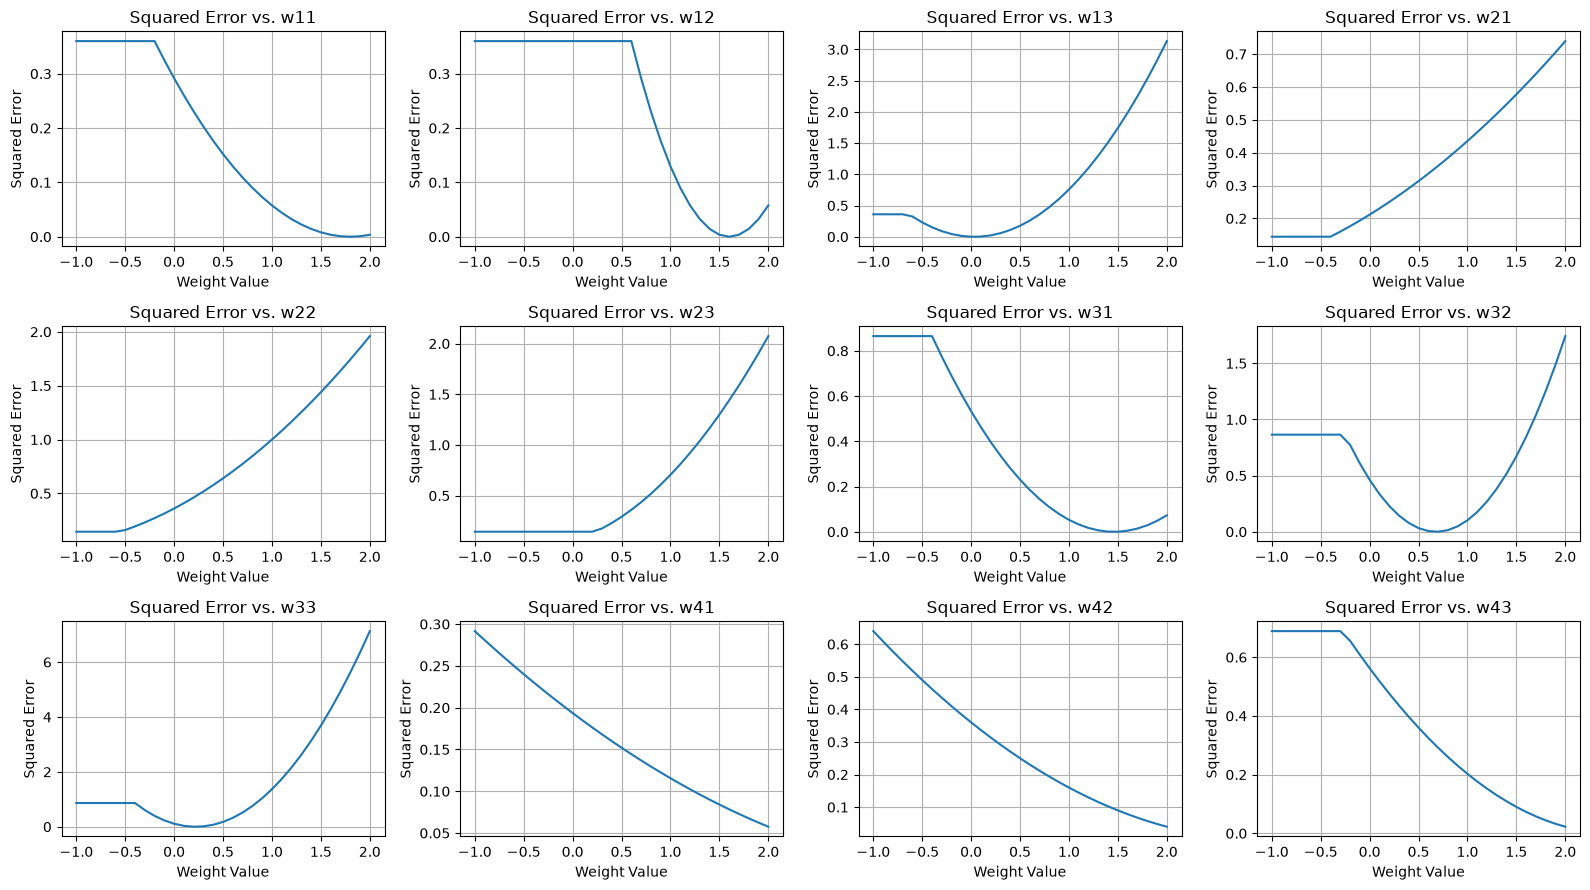

In [5]:
plt.figure(figsize=(16, 9))

for i, weight_name in enumerate(weight_loss_values): 
     
    plt.subplot(3, 4, i + 1) 
     
    plt.plot( 
        weight_range, 
        weight_loss_values[weight_name] 
    ) 
     
    plt.xlabel("Weight Value") 
    plt.ylabel("Squared Error") 
    plt.title(f"Squared Error vs. {weight_name}") 
     
    plt.grid(True) 

plt.tight_layout()
plt.show()

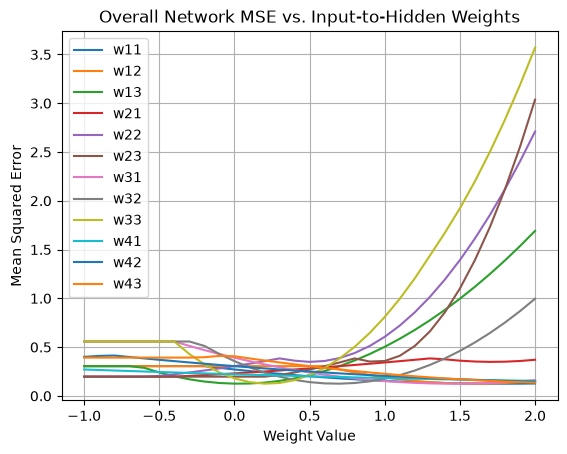

In [6]:
plt.figure()

for weight_name in mse_curves:
    plt.plot(
        weight_range,
        mse_curves[weight_name],
        label=weight_name
    )

plt.xlabel("Weight Value")
plt.ylabel("Mean Squared Error")
plt.title("Overall Network MSE vs. Input-to-Hidden Weights")

plt.legend()
plt.grid(True)

plt.show()

# 5. Sayısal türev (numerical derivative) ile basit bir gradient descent döngüsü kur: parametreyi küçük adımlarla güncelleyerek loss'u düşür.

- Numerical Derivative and Gradient Descent

Gradient descent is an optimization method used to reduce the loss of a neural network by updating its parameters in the direction that decreases the loss.

To determine which direction a parameter should move, I use a numerical derivative. Instead of calculating the derivative analytically, I slightly increase the parameter and observe how the loss changes.

The numerical derivative can be approximated as:

f'(x) ≈ (f(x + h) - f(x)) / h

If the derivative is positive, decreasing the parameter can reduce the loss. If it is negative, increasing the parameter can reduce the loss.

The parameter is updated using the gradient descent rule:

parameter = parameter - learning_rate × gradient

In this section, I select one weight from the input-to-hidden layer and use its numerical derivative to update it iteratively. The other parameters remain constant.

The goal is to observe whether the loss decreases as the selected parameter is updated.

In [7]:
def numerical_derivative(loss_function, parameter, h=0.0001):
    """Numerical derivative kullanarak parametrenin gradientini hesaplar."""
    
    loss_current = loss_function(parameter)
    loss_increased = loss_function(parameter + h)
    
    gradient = (loss_increased - loss_current) / h
    
    return gradient

In [8]:
# Input values
inputs = [1.0, 2.0, 3.0]

# Target values for the two output neurons
y_true = [1.0, 0.5]


# Select the parameter to optimize
neuron_index = 0
weight_index = 0

# Initial value of the selected weight
weight_value = weights_list[0][neuron_index][weight_index]

# Gradient descent settings
learning_rate = 0.1
iterations = 100

# Store results
weight_history = []
loss_history = []


# Gradient descent loop
for iteration in range(iterations):
    
    # Define the loss for the current weight value
    def loss_function(parameter):
        
        weights_list[0][neuron_index][weight_index] = parameter
        
        predictions = forward_pass_network(
            inputs,
            weights_list,
            biases_list,
            activation="relu"
        )
        
        loss = mean_squared_error(
            y_true,
            predictions
        )
        
        return loss
    
    
    # Calculate numerical derivative
    gradient = numerical_derivative(
        loss_function,
        weight_value
    )
    
    # Update the weight using gradient descent
    weight_value = weight_value - learning_rate * gradient
    
    # Calculate the new loss
    loss = loss_function(weight_value)
    
    # Store results
    weight_history.append(weight_value)
    loss_history.append(loss)


# Set the final weight value
weights_list[0][neuron_index][weight_index] = weight_value

print(f"Final weight value: {weight_value:.4f}")
print(f"Final loss: {loss_history[-1]:.4f}")

Final weight value: 0.1603
Final loss: 0.1250


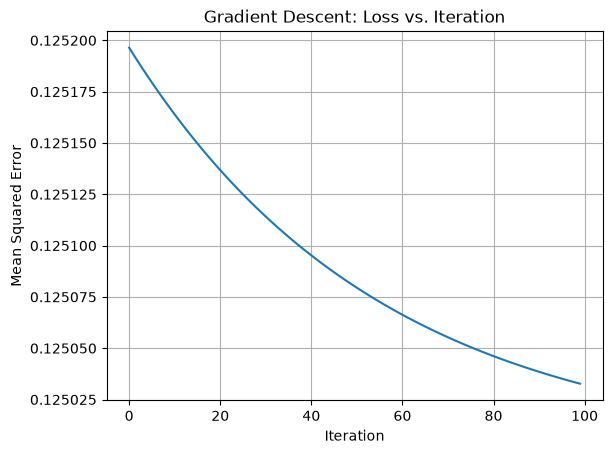

In [9]:
plt.plot(range(iterations), loss_history)

plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Descent: Loss vs. Iteration")

plt.grid(True)

plt.show()

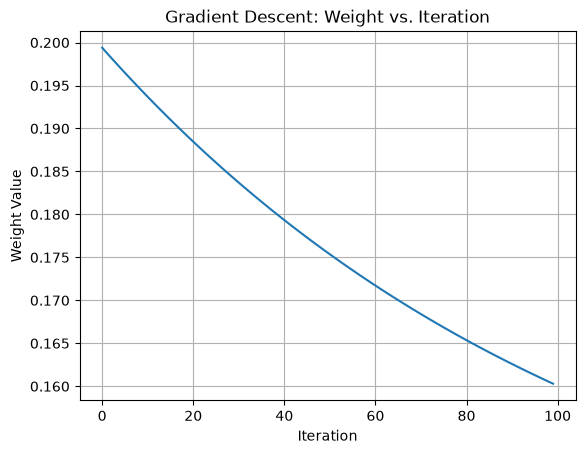

In [10]:
plt.plot(range(iterations), weight_history)

plt.xlabel("Iteration")
plt.ylabel("Weight Value")
plt.title("Gradient Descent: Weight vs. Iteration")

plt.grid(True)

plt.show()